## Encode categorical variables

Convert categorical features into a numerical format that can be used by machine learning algorithms.


In [ ]:
categorical_cols_to_encode = ['gender', 'country', 'cancer_stage', 'smoking_status', 'treatment_type']
df = pd.get_dummies(df, columns=categorical_cols_to_encode) # Removed drop_first=True
print("DataFrame columns after one-hot encoding:")
print(list(df.columns))

DataFrame columns after one-hot encoding:
['id', 'age', 'diagnosis_date', 'family_history', 'bmi', 'cholesterol_level', 'hypertension', 'asthma', 'cirrhosis', 'other_cancer', 'end_treatment_date', 'survived', 'gender_Female', 'gender_Male', 'country_Austria', 'country_Belgium', 'country_Bulgaria', 'country_Croatia', 'country_Cyprus', 'country_Czech Republic', 'country_Denmark', 'country_Estonia', 'country_Finland', 'country_France', 'country_Germany', 'country_Greece', 'country_Hungary', 'country_Ireland', 'country_Italy', 'country_Latvia', 'country_Lithuania', 'country_Luxembourg', 'country_Malta', 'country_Netherlands', 'country_Poland', 'country_Portugal', 'country_Romania', 'country_Slovakia', 'country_Slovenia', 'country_Spain', 'country_Sweden', 'cancer_stage_Stage I', 'cancer_stage_Stage II', 'cancer_stage_Stage III', 'cancer_stage_Stage IV', 'smoking_status_Current Smoker', 'smoking_status_Former Smoker', 'smoking_status_Never Smoked', 'smoking_status_Passive Smoker', 'treatmen


Visualizing encoding for: gender


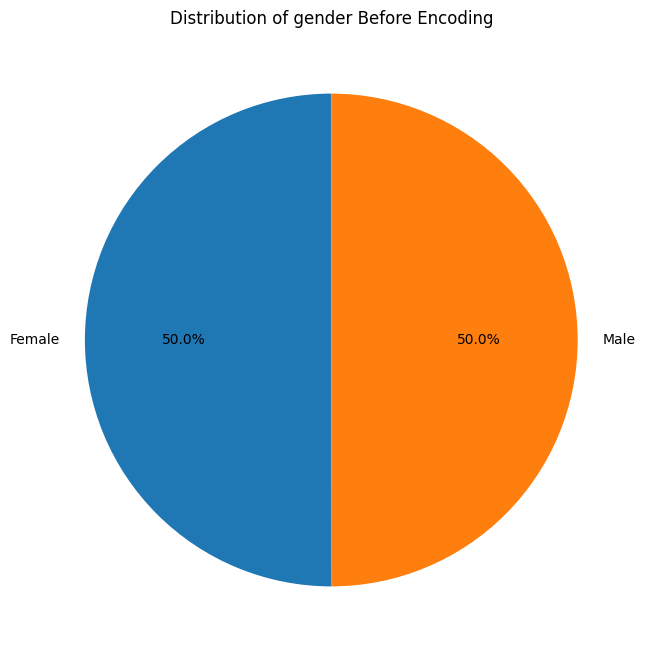

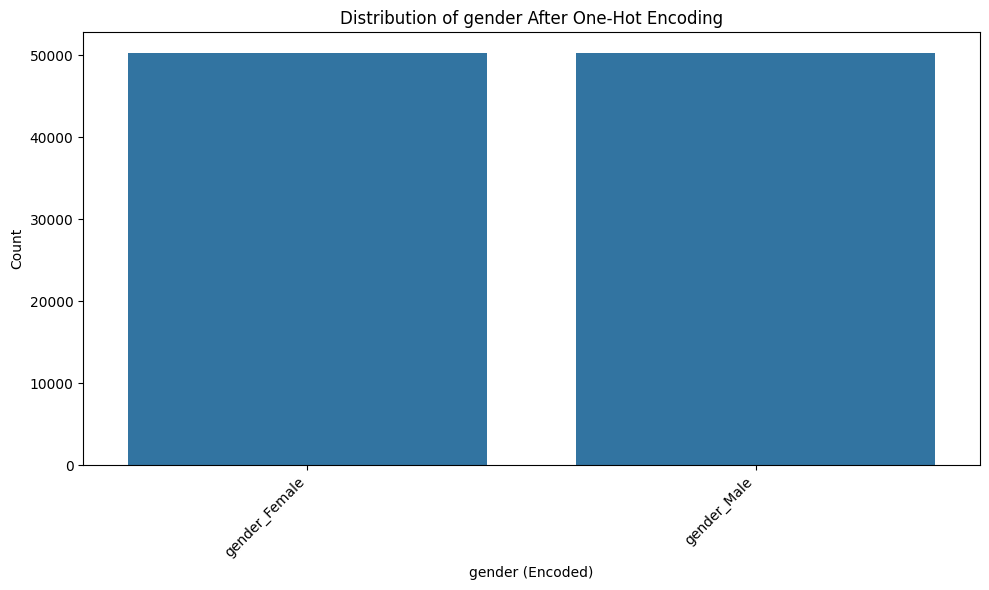


Counts of gender after One-Hot Encoding:
  gender (Encoded)  Count
0    gender_Female  50270
1      gender_Male  50238

Visualizing encoding for: country


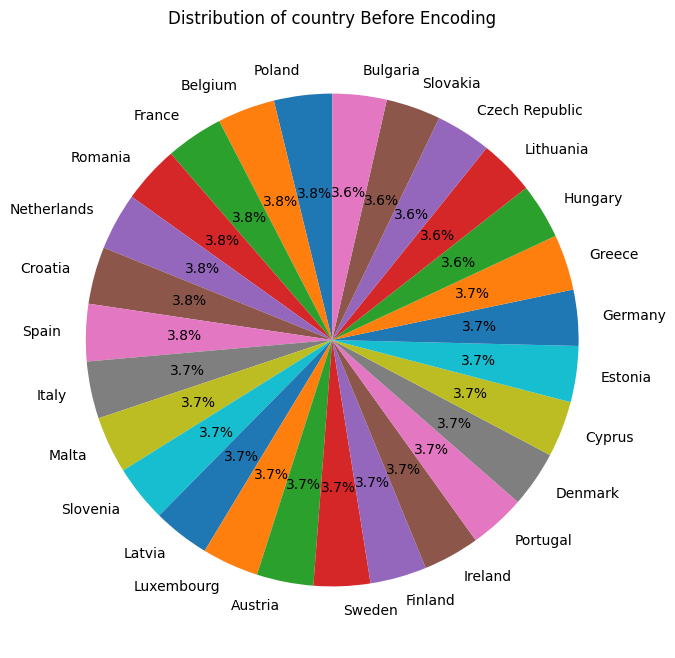

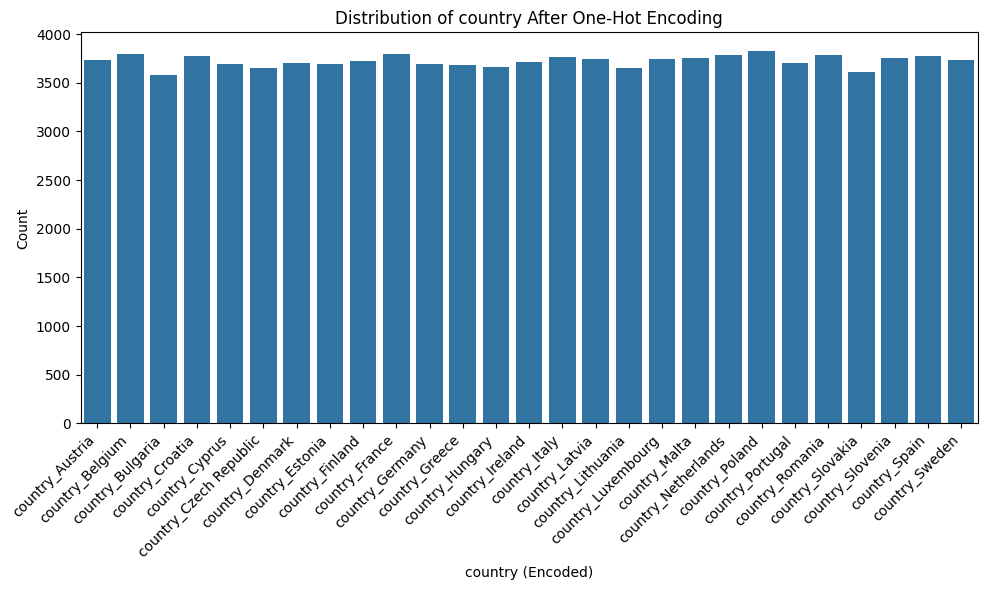


Counts of country after One-Hot Encoding:
         country (Encoded)  Count
0          country_Austria   3736
1          country_Belgium   3796
2         country_Bulgaria   3580
3          country_Croatia   3774
4           country_Cyprus   3693
5   country_Czech Republic   3648
6          country_Denmark   3702
7          country_Estonia   3693
8          country_Finland   3726
9           country_France   3791
10         country_Germany   3690
11          country_Greece   3678
12         country_Hungary   3658
13         country_Ireland   3717
14           country_Italy   3768
15          country_Latvia   3744
16       country_Lithuania   3656
17      country_Luxembourg   3740
18           country_Malta   3755
19     country_Netherlands   3786
20          country_Poland   3826
21        country_Portugal   3706
22         country_Romania   3787
23        country_Slovakia   3605
24        country_Slovenia   3754
25           country_Spain   3771
26          country_Sweden   3728

Visu

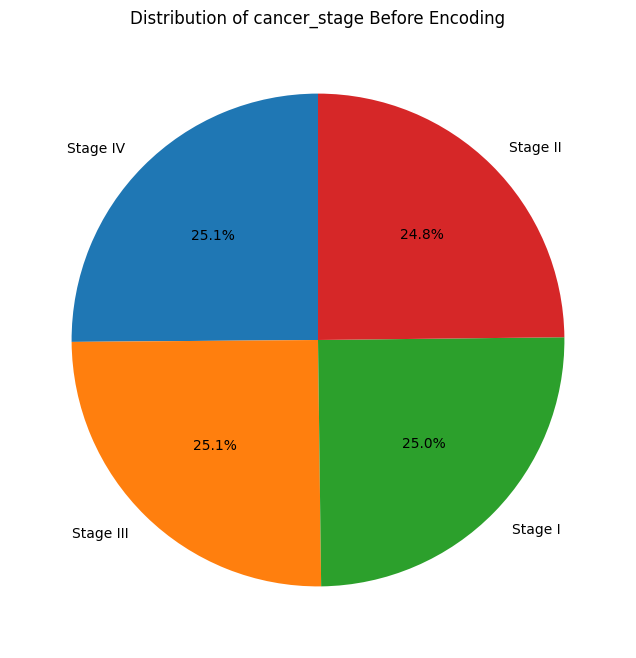

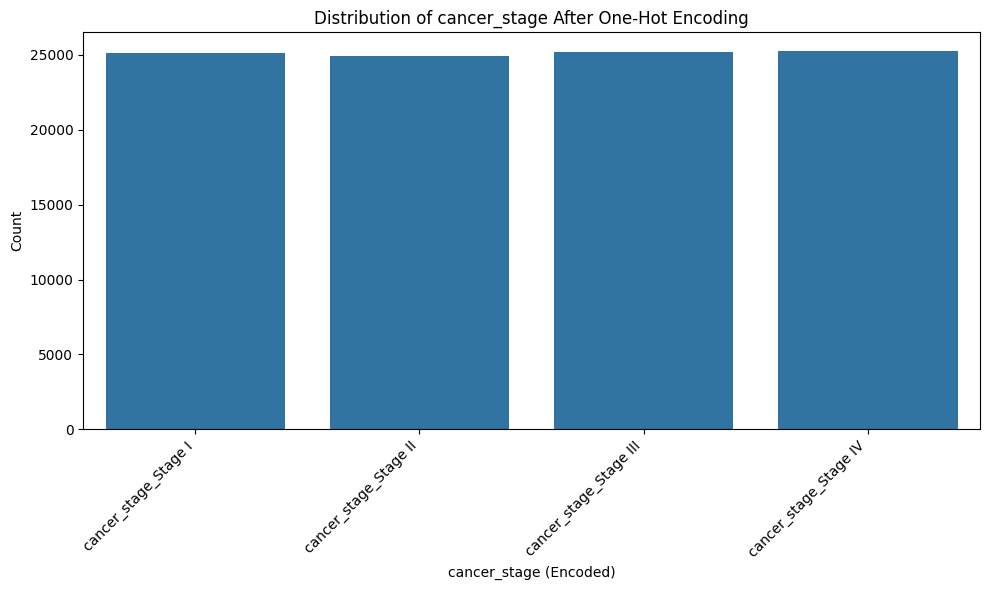


Counts of cancer_stage after One-Hot Encoding:
   cancer_stage (Encoded)  Count
0    cancer_stage_Stage I  25102
1   cancer_stage_Stage II  24947
2  cancer_stage_Stage III  25208
3   cancer_stage_Stage IV  25251

Visualizing encoding for: smoking_status


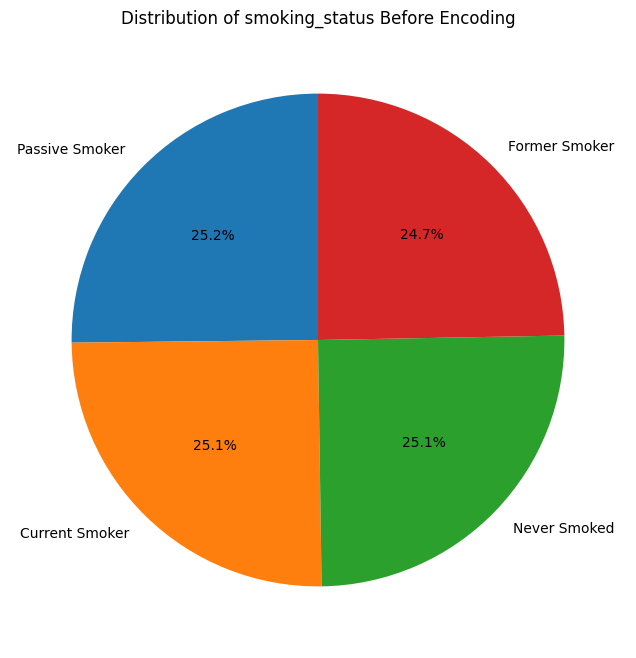

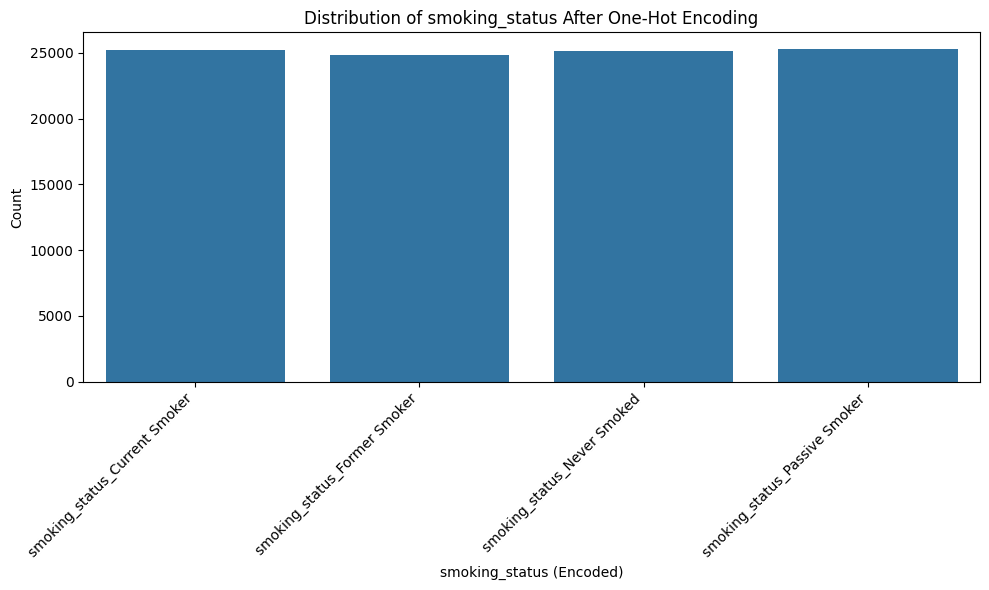


Counts of smoking_status after One-Hot Encoding:
        smoking_status (Encoded)  Count
0  smoking_status_Current Smoker  25187
1   smoking_status_Former Smoker  24837
2    smoking_status_Never Smoked  25183
3  smoking_status_Passive Smoker  25301

Visualizing encoding for: treatment_type


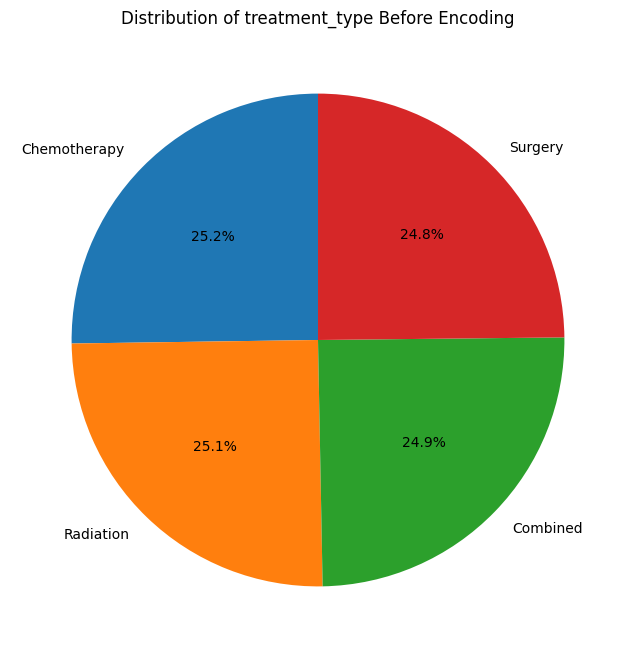

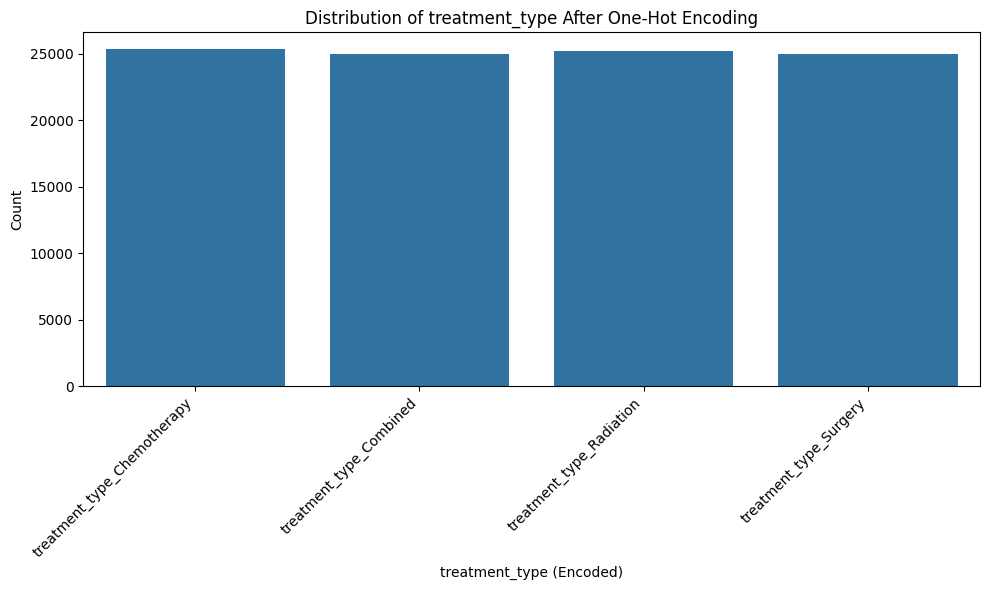


Counts of treatment_type after One-Hot Encoding:
      treatment_type (Encoded)  Count
0  treatment_type_Chemotherapy  25356
1      treatment_type_Combined  24995
2     treatment_type_Radiation  25200
3       treatment_type_Surgery  24957


In [ ]:
# Define the list of categorical columns to visualize encoding for
categorical_cols_to_encode_viz = ['gender', 'country', 'cancer_stage', 'smoking_status', 'treatment_type']

# Ensure df_original_smoking is defined for "before" visualization
df_original_encoding = pd.read_csv("/content/drive/MyDrive/Colab Notebooks/LungCancer_DataSet.csv")

# Fill missing values in these columns with mode for visualization as done previously
for col in categorical_cols_to_encode_viz:
    df_original_encoding[col] = df_original_encoding[col].fillna(df_original_encoding[col].mode()[0])


for col in categorical_cols_to_encode_viz:
    print(f"\nVisualizing encoding for: {col}")

    # Create a pie chart for the original column before encoding
    plt.figure(figsize=(8, 8))
    df_original_encoding[col].value_counts().plot.pie(autopct='%1.1f%%', startangle=90)
    plt.title(f'Distribution of {col} Before Encoding')
    plt.ylabel('') # Hide the default y-label for pie charts
    plt.show()

    # Create a bar plot for the one-hot encoded columns after encoding
    # Find the columns in the processed df that correspond to the original categorical column
    encoded_cols = [c for c in df.columns if c.startswith(f'{col}_')]
    if encoded_cols: # Check if any encoded columns were found
        df_encoded_counts = df[encoded_cols].sum().reset_index()
        df_encoded_counts.columns = [f'{col} (Encoded)', 'Count']

        plt.figure(figsize=(10, 6))
        sns.barplot(data=df_encoded_counts, x=f'{col} (Encoded)', y='Count')
        plt.title(f'Distribution of {col} After One-Hot Encoding')
        plt.xlabel(f'{col} (Encoded)')
        plt.ylabel('Count')
        plt.xticks(rotation=45, ha='right')
        plt.tight_layout()
        plt.show()

        print(f"\nCounts of {col} after One-Hot Encoding:")
        print(df_encoded_counts)
    else:
        print(f"No one-hot encoded columns found for {col}.")